In [45]:
#Imports
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 511
rng = np.random.default_rng(SEED)
random.seed(SEED)


In [46]:
# Utility: timing helper
def time_function(fn, *args, repeat=5, **kwargs):
    """Return the best of `repeat` wall-clock timings for fn(*args, **kwargs)."""
    best = float('inf')
    result = None
    for _ in range(repeat):
        start = time.perf_counter()
        out = fn(*args, **kwargs)
        elapsed = time.perf_counter() - start
        if elapsed < best:
            best = elapsed
            result = out
    return best, result

print("Environment ready.")

Environment ready.


In [48]:
def run_sorting_experiment(sizes, repeat=3, insertion_sort_cap=20_000):
    """
    Run the sorting benchmark for multiple input sizes.

    Parameters
    ----------
    sizes : list
        Input sizes to test.
    repeat : int
        Number of timing repetitions.
    insertion_sort_cap : int
        Maximum input size for insertion sort.

    Returns
    -------
    pandas.DataFrame
        Runtime results for the three sorting methods.
    """
    results = {
        'n': [],
        'sorted_builtin': [],
        'insertion_sort': [],
        'numpy_sort': []
    }

    for n in sizes:

        data = rng.integers(
            low=0,
            high=10_000_000,
            size=n,
            dtype=np.int64
        )

        # Python built-in sorting
        t_sorted, _ = time_function(
            sorted, data, repeat=repeat
        )

        # NumPy sorting
        t_numpy, _ = time_function(
            np.sort, data, repeat=repeat
        )

        # Insertion sorting
        if n <= insertion_sort_cap:
            t_insert, _ = time_function(
                insertion_sort, data, repeat=repeat
            )
        else:
            t_insert = np.nan

        results['n'].append(n)
        results['sorted_builtin'].append(t_sorted)
        results['insertion_sort'].append(t_insert)
        results['numpy_sort'].append(t_numpy)

    return pd.DataFrame(results)

sorting_sizes = [5_000, 10_000, 20_000]
sorting_repeat = 3
insertion_sort_cap = 20_000

dfA = run_sorting_experiment(
    sizes=sorting_sizes,
    repeat=sorting_repeat,
    insertion_sort_cap=insertion_sort_cap
)

dfA

,n,sorted_builtin,insertion_sort,numpy_sort
0,5000,0.002462,0.910168,0.000104
1,10000,0.004546,3.700464,0.000152
2,20000,0.009693,16.839639,0.000349


In [50]:
def plot_sorting_results(df):
    """
    Plot sorting benchmark results.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing sorting runtime results.

    Returns
    -------
    None
        Displays log-log and linear runtime plots.
    """

    methods = ['sorted_builtin', 'numpy_sort', 'insertion_sort']

    # Log-log plot
    plt.figure()

    for method in methods:
        plt.plot(
            df['n'],
            df[method],
            marker='o',
            label=method
        )

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Input size (n)')
    plt.ylabel('Runtime (seconds)')
    plt.title('Sorting Runtime vs Input Size (Log-Log)')
    plt.legend()
    plt.grid(True)
    plt.show()

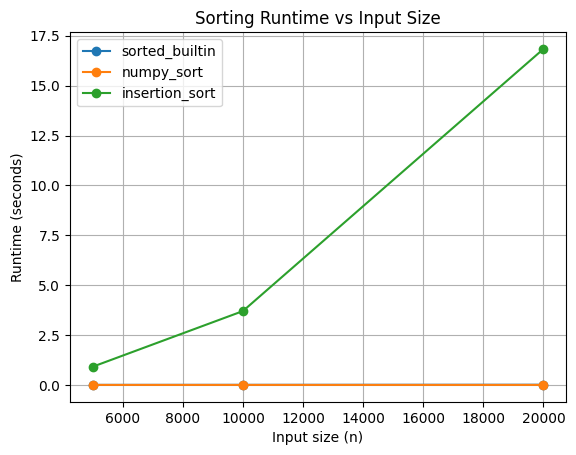

In [52]:
# Linear plot
methods = ['sorted_builtin', 'numpy_sort', 'insertion_sort']
df = dfA

plt.figure()

for method in methods:
    plt.plot(
        df['n'],
        df[method],
        marker='o',
        label=method
    )

plt.xlabel('Input size (n)')
plt.ylabel('Runtime (seconds)')
plt.title('Sorting Runtime vs Input Size')
plt.legend()
plt.grid(True)
plt.show()

Starting plot...


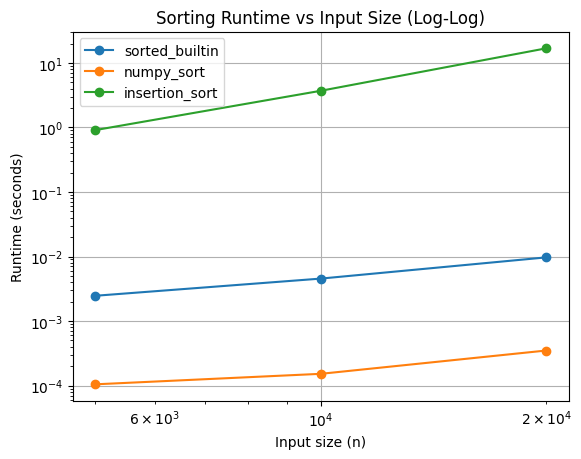

Plot finished...


In [53]:
print("Starting plot...")
plot_sorting_results(dfA)
print("Plot finished...")

In [54]:
sizes_B = [10_000, 100_000, 500_000]
queries_per_size = 1_000

def gen_ids(n):
    ids = [f"id_{i:07d}" for i in range(n)]
    rng.shuffle(ids)
    return ids

def membership_timing(ids, structure_type='list'):
    if structure_type == 'list':
        coll = list(ids)
        def contains(x): return x in coll
    elif structure_type == 'set':
        coll = set(ids)
        def contains(x): return x in coll
    elif structure_type == 'dict':
        coll = {x: True for x in ids}
        def contains(x): return x in coll

    present = rng.choice(ids, size=queries_per_size//2, replace=False)
    absent = [f"nope_{i:07d}" for i in range(queries_per_size - len(present))]
    queries = np.concatenate([present, absent])
    rng.shuffle(queries)

    start = time.perf_counter()
    for q in queries:
        _ = contains(q)
    elapsed = time.perf_counter() - start
    return elapsed

records = {'n': [], 'structure': [], 'time_s': []}

for n in sizes_B:
    ids = gen_ids(n)
    for stype in ['list', 'set', 'dict']:
        t = membership_timing(ids, structure_type=stype)
        records['n'].append(n)
        records['structure'].append(stype)
        records['time_s'].append(t)

dfB = pd.DataFrame(records)
dfB

,n,structure,time_s
0,10000,list,0.117233
1,10000,set,0.000576
2,10000,dict,0.000471
3,100000,list,6.033502
4,100000,set,0.000722
5,100000,dict,0.000934
6,500000,list,48.717197
7,500000,set,0.000882
8,500000,dict,0.001216


In [57]:
def plot_membership_results(df):
    """
    Plot membership testing time for different data structures.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing membership timing results.

    Returns
    -------
    None
        Displays the membership timing plot.
    """
    structures = ['list', 'set', 'dict']

    plt.figure()

    for structure in structures:
        subset = df[df['structure'] == structure]

        plt.plot(
            subset['n'],
            subset['time_s'],
            marker='o',
            label=structure
        )

    plt.xlabel('Input size (n)')
    plt.ylabel('Total time for membership queries (s)')
    plt.title('Membership Testing Time vs Input Size')
    plt.legend()
    plt.grid(True)
    plt.show()

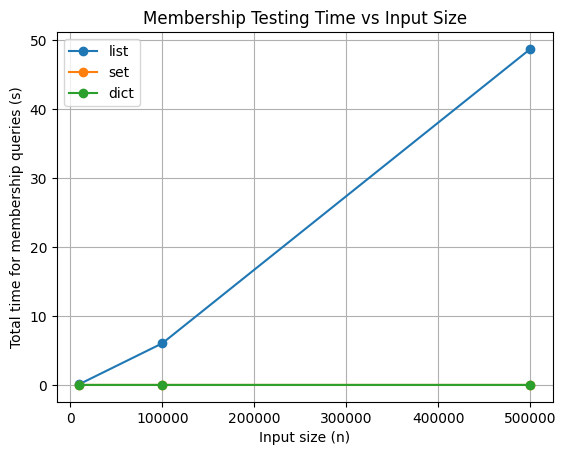

In [58]:
plot_membership_results(dfB)

In [59]:
# Test 1: Normal case
result = insertion_sort([5, 2, 4, 1, 3])
expected = [1, 2, 3, 4, 5]

assert result == expected, f"Expected {expected}, got {result}"

print("Test 1 passed: insertion_sort works for a normal case.")


# Test 2: Edge case
result = insertion_sort([])
expected = []

assert result == expected, f"Expected {expected}, got {result}"

print("Test 2 passed: insertion_sort works for an empty list.")

Test 1 passed: insertion_sort works for a normal case.
Test 2 passed: insertion_sort works for an empty list.


In [60]:
# Test 3: Verify the refactored sorting experiment
# produces the expected result structure.

expected_columns = [
    'n',
    'sorted_builtin',
    'insertion_sort',
    'numpy_sort'
]

assert list(dfA.columns) == expected_columns, (
    f"Expected columns {expected_columns}, got {list(dfA.columns)}"
)

assert list(dfA['n']) == [5_000, 10_000, 20_000], (
    f"Unexpected input sizes: {list(dfA['n'])}"
)

print("Test 3 passed: refactored sorting experiment preserves the expected output structure.")

Test 3 passed: refactored sorting experiment preserves the expected output structure.
